# TV sweep (second_order) ? stride_x=stride_t=10

Sweeps `lam_tv ? {0, 1e-3, 0.1, 1, 10}` with a `second_order` TV penalty.

**Controls**
- `stride_x = 10`, `stride_t = 10`
- `noise = 0.7`, `nu = 0.02`
- `steps = 8000`, `lr = 0.001`, `batch_size = 1000`
- `lam_pde = 0.5`, `lam_data = 10`, `lam_reg = 0`

**Dependents (table outputs)**
- Final `loss_data`, `loss_pde`, **`loss_tv`**
- `w_u`, `w_ux`, `w_uxx`, `w_prod` from `eql.readout.weight`
- `M01`, `M10` from `eql.effective_quadratic_matrix(symmetrize=False)`

TV definition used in this notebook:
```python
def second_order_tv_1d(u: torch.Tensor, x: torch.Tensor, eps: float = 1e-6, reduce: str = "mean"):
    """returns Monte Carlo estimate of E[sqrt(u_xx^2 + eps^2)]"""
    ux = grad_scalar(u, x)
    uxx = grad_scalar(ux, x)
    val = torch.sqrt(uxx**2 + eps**2)
    if reduce == "mean":
        return val.mean()
    if reduce == "sum":
        return val.sum()
    return val

```


In [1]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [2]:
# Controls

steps = 8000
log_every = 1000

noise = 0.7
nu = 0.02

stride_x = 10
stride_t = 10

lr = 1e-3
batch_size = 1000

lam_pde = 0.5
lam_data = 10.0
lam_reg = 0.0

selected_derivs = ('u','u_x','u_xx')

lam_tv_values = [0.0, 1e-3, 0.1, 1.0, 10.0]

# Dataset partitioning controls
part_num = 1
which_part = 1


In [3]:
# Build dataset (fixed stride_x=stride_t=10)

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=SEED,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, _N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 676
x_unique: 26 t_unique: 26


In [4]:
# TV functions + wrapper

def grad_scalar(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

def second_order_tv_1d(u: torch.Tensor, x: torch.Tensor, eps: float = 1e-6, reduce: str = "mean"):
    """returns Monte Carlo estimate of E[sqrt(u_xx^2 + eps^2)]"""
    ux = grad_scalar(u, x)
    uxx = grad_scalar(ux, x)
    val = torch.sqrt(uxx**2 + eps**2)
    if reduce == "mean":
        return val.mean()
    if reduce == "sum":
        return val.sum()
    return val


def tv_fn(u_model, t, x):
    u = u_model(t, x)
    return second_order_tv_1d(u, x)


In [10]:
def run_once(lam_tv: float):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=mlps.Sin)
    symnet  = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=1, bias=False)

    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    train = trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

    loss_dat = []
    loss_pde = []
    loss_tv  = []

    for i in range(steps):
        t, x, u_noisy, u_clean = hlprs.make_batch(
            batch_size=batch_size,
            t_torch=t_torch,
            x_torch=x_torch,
            y_clean=y_clean_torch,
            y_noisy=y_noisy_torch,
        )
        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean, tv_fn=tv_fn)
        loss_dat.append(out['loss_data'])
        loss_pde.append(out['loss_pde'])
        loss_tv.append(out['loss_tv'])

        if log_every and i % log_every == 0:
            print(f"[lam_tv={lam_tv:g}] step {i}: data={out['loss_data']:.6e} pde={out['loss_pde']:.6e} tv={out['loss_tv']:.6e}")

    w = symnet.readout.weight.detach().cpu().numpy().reshape(-1)
    M = symnet.effective_quadratic_matrix(symmetrize=False).detach().cpu().numpy()
    print(hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0])

    return {
        'lam_tv': float(lam_tv),
        'loss_data_final': float(loss_dat[-1]),
        'loss_pde_final': float(loss_pde[-1]),
        'loss_tv_final': float(loss_tv[-1]),
        'w_u': float(w[0]),
        'w_ux': float(w[1]),
        'w_uxx': float(w[2]),
        'w_prod': float(w[-1]),
        'M01': float(M[0,1]),
        'M10': float(M[1,0]),
        'loss_data_curve': loss_dat,
        'loss_pde_curve': loss_pde,
        'loss_tv_curve': loss_tv,
    }


Running lam_tv = 0.0
[lam_tv=0] step 0: data=1.003832e+00 pde=7.057870e-03 tv=8.991058e-03
[lam_tv=0] step 1000: data=5.299358e-01 pde=1.144374e-02 tv=1.175215e+00
[lam_tv=0] step 2000: data=5.446492e-01 pde=4.276993e-02 tv=2.349008e+00
[lam_tv=0] step 3000: data=4.793340e-01 pde=9.032410e-02 tv=3.336746e+00
[lam_tv=0] step 4000: data=4.937606e-01 pde=9.982084e-02 tv=3.603797e+00
[lam_tv=0] step 5000: data=4.592702e-01 pde=1.218407e-01 tv=3.437748e+00
[lam_tv=0] step 6000: data=4.963461e-01 pde=1.755966e-01 tv=4.364619e+00
[lam_tv=0] step 7000: data=4.618628e-01 pde=1.839339e-01 tv=5.802914e+00
max_abs_diff = 0.664948
()
Running lam_tv = 0.001
[lam_tv=0.001] step 0: data=1.003832e+00 pde=7.057870e-03 tv=8.991058e-03
[lam_tv=0.001] step 1000: data=5.299363e-01 pde=1.136190e-02 tv=1.169818e+00
[lam_tv=0.001] step 2000: data=5.446213e-01 pde=4.245522e-02 tv=2.326042e+00
[lam_tv=0.001] step 3000: data=4.793514e-01 pde=9.007714e-02 tv=3.275006e+00
[lam_tv=0.001] step 4000: data=4.939522e-01

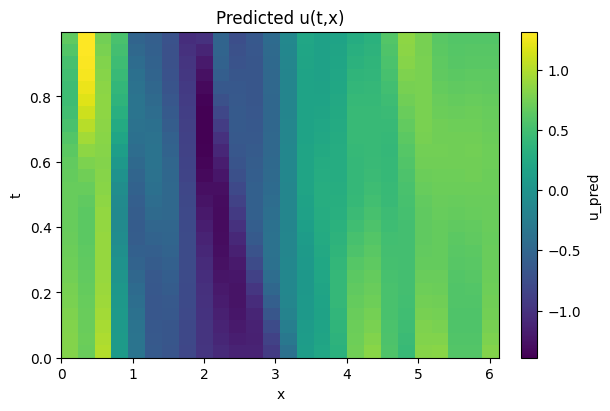

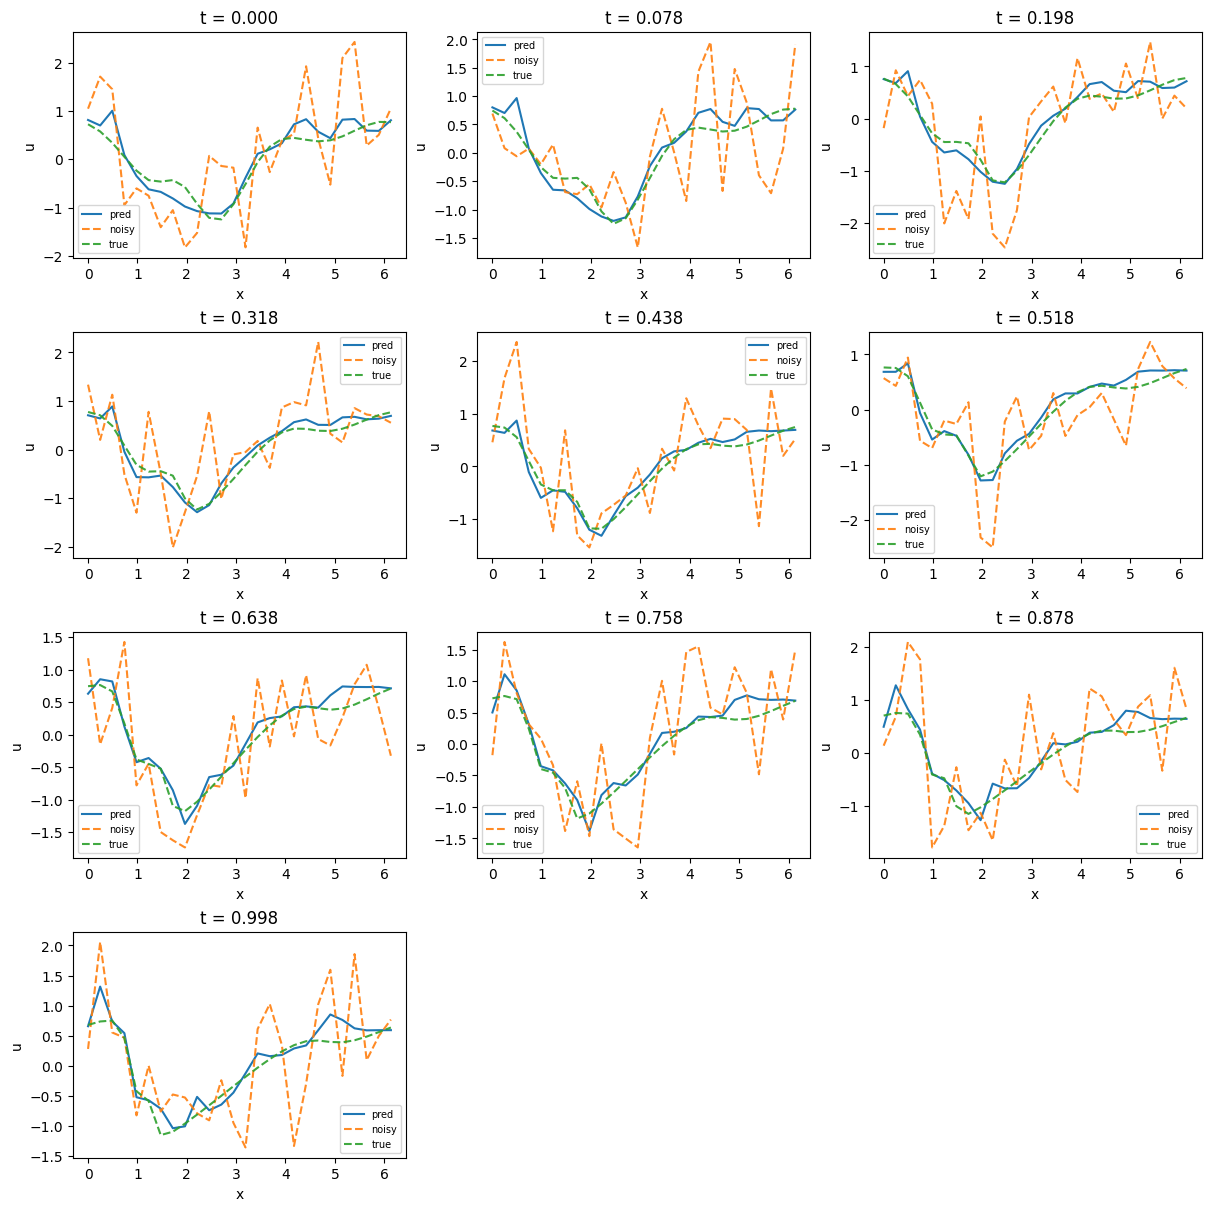

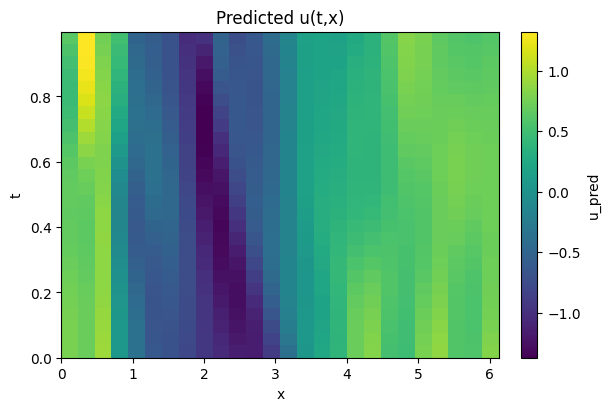

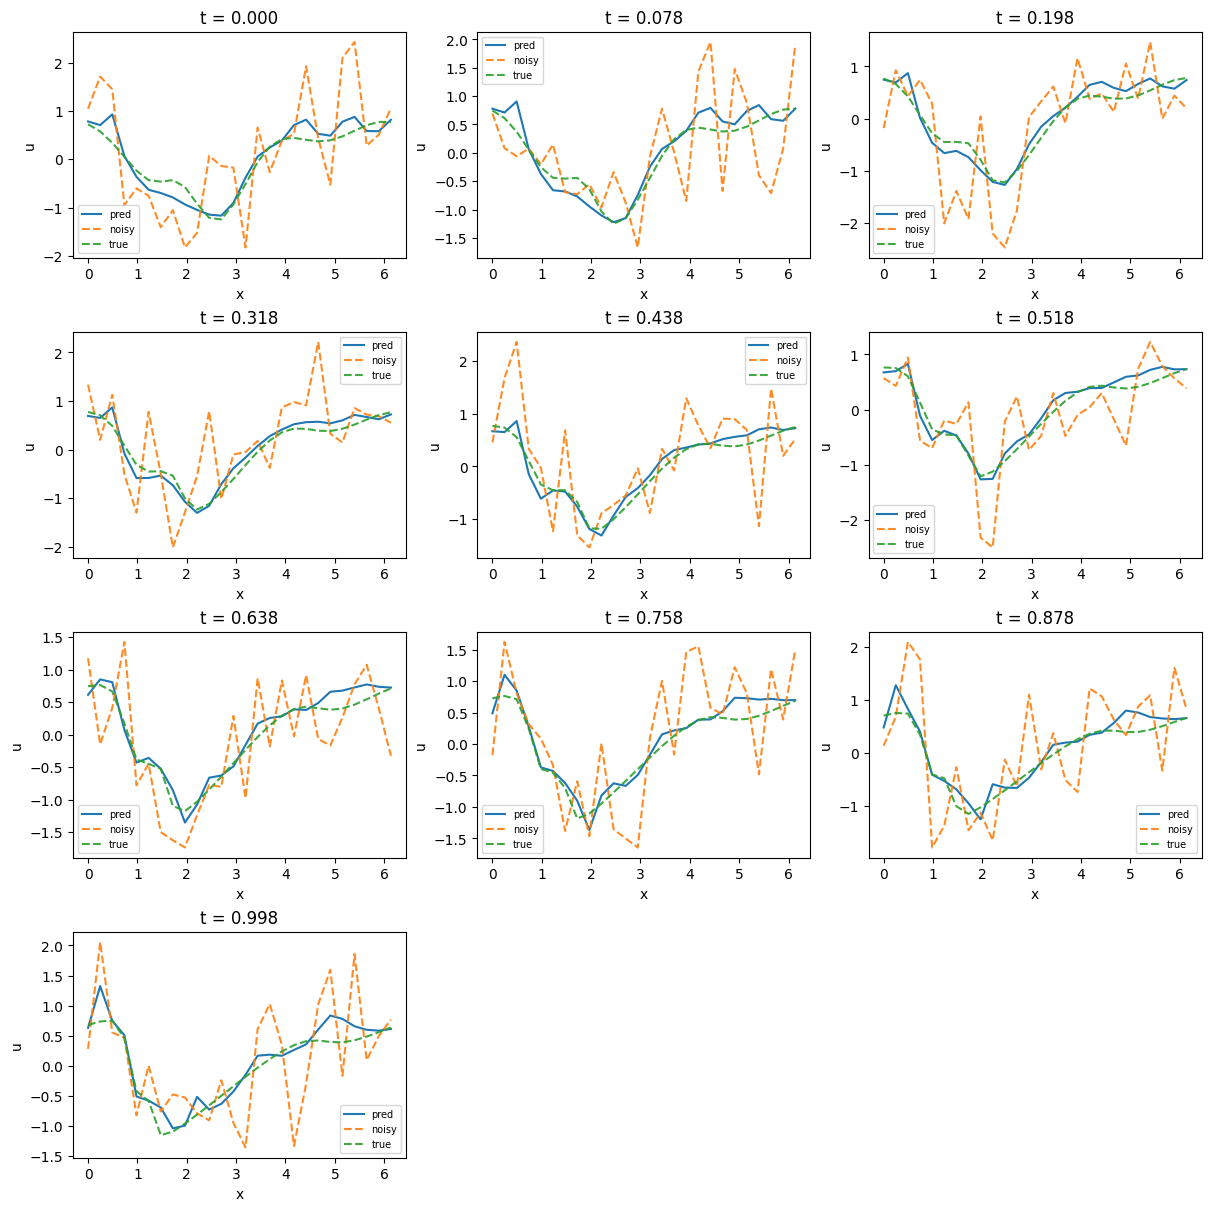

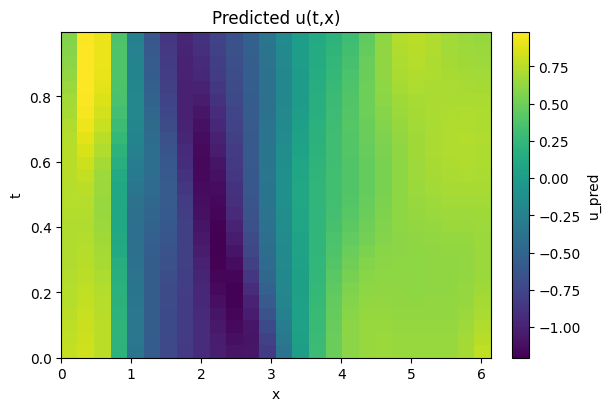

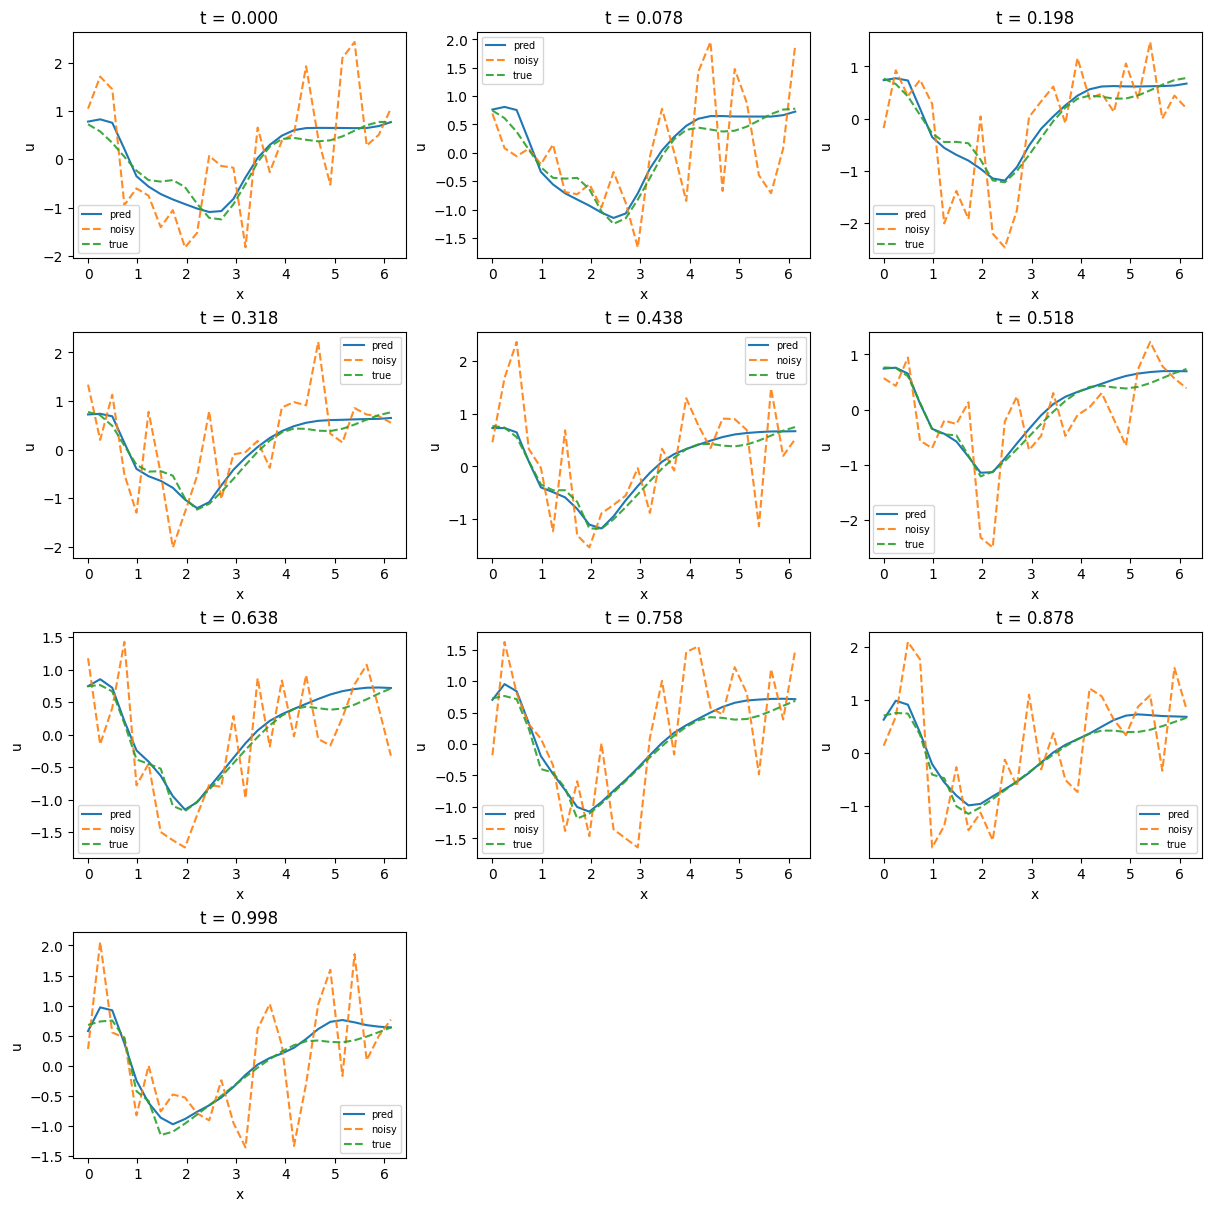

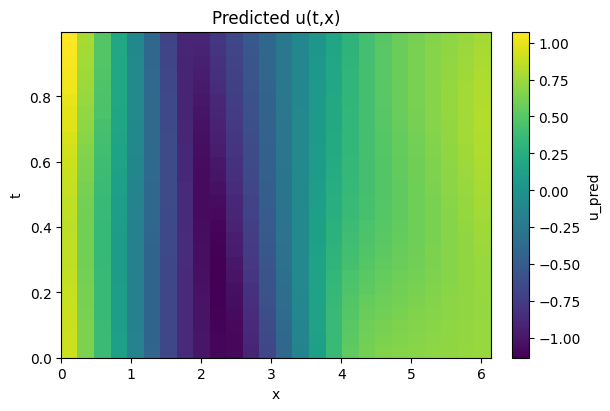

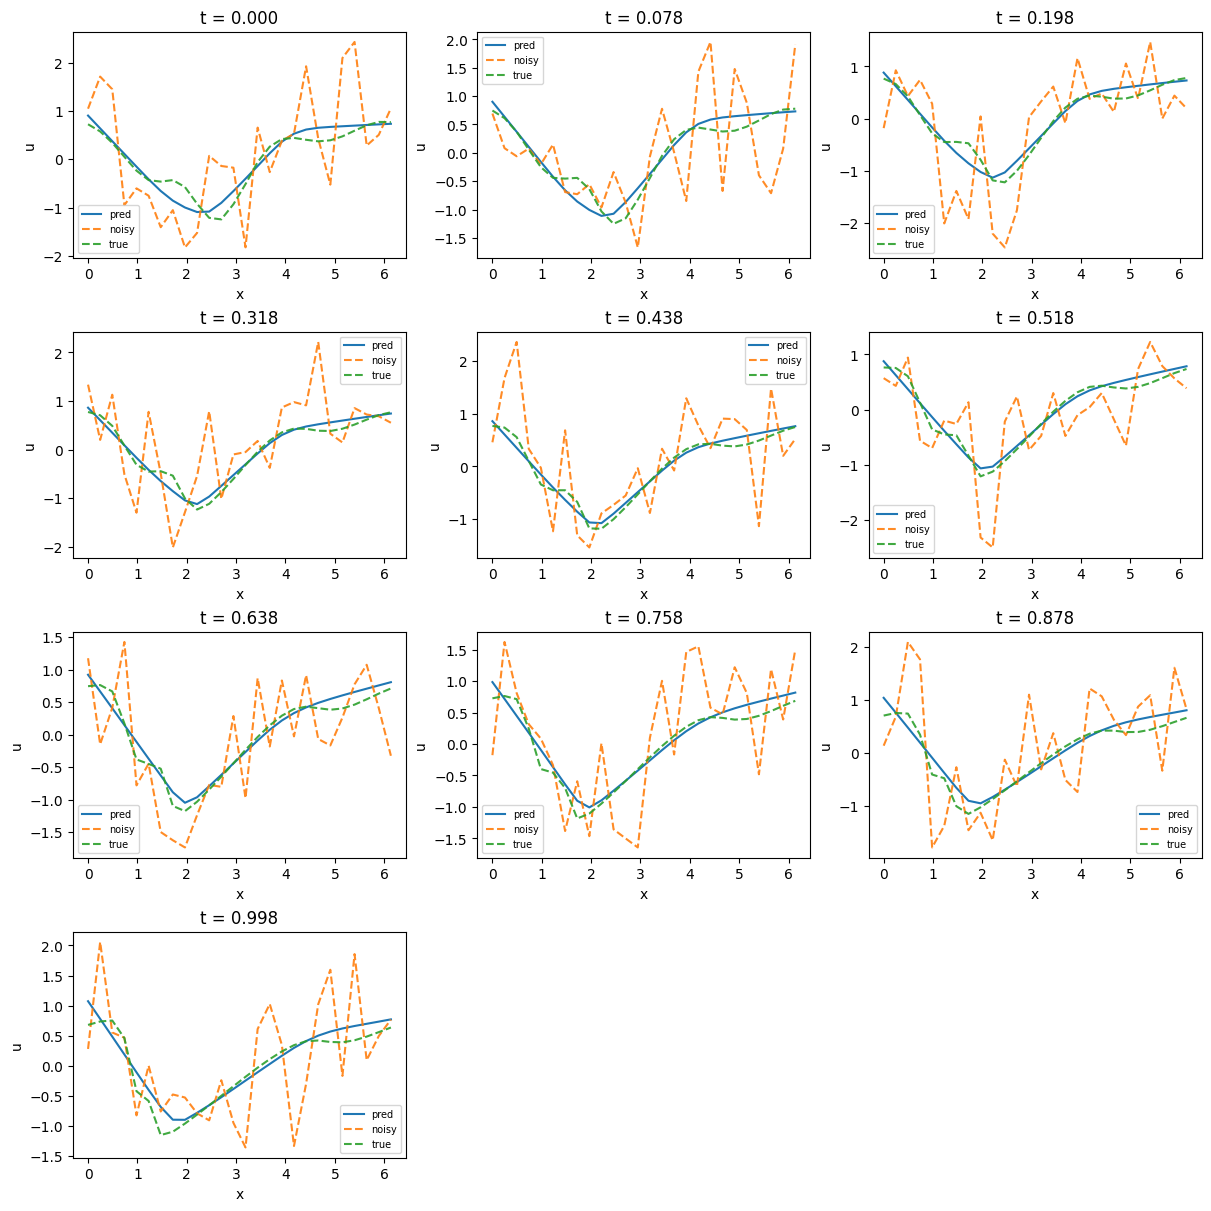

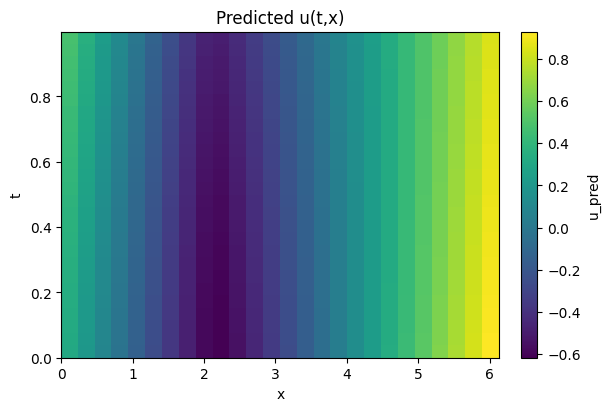

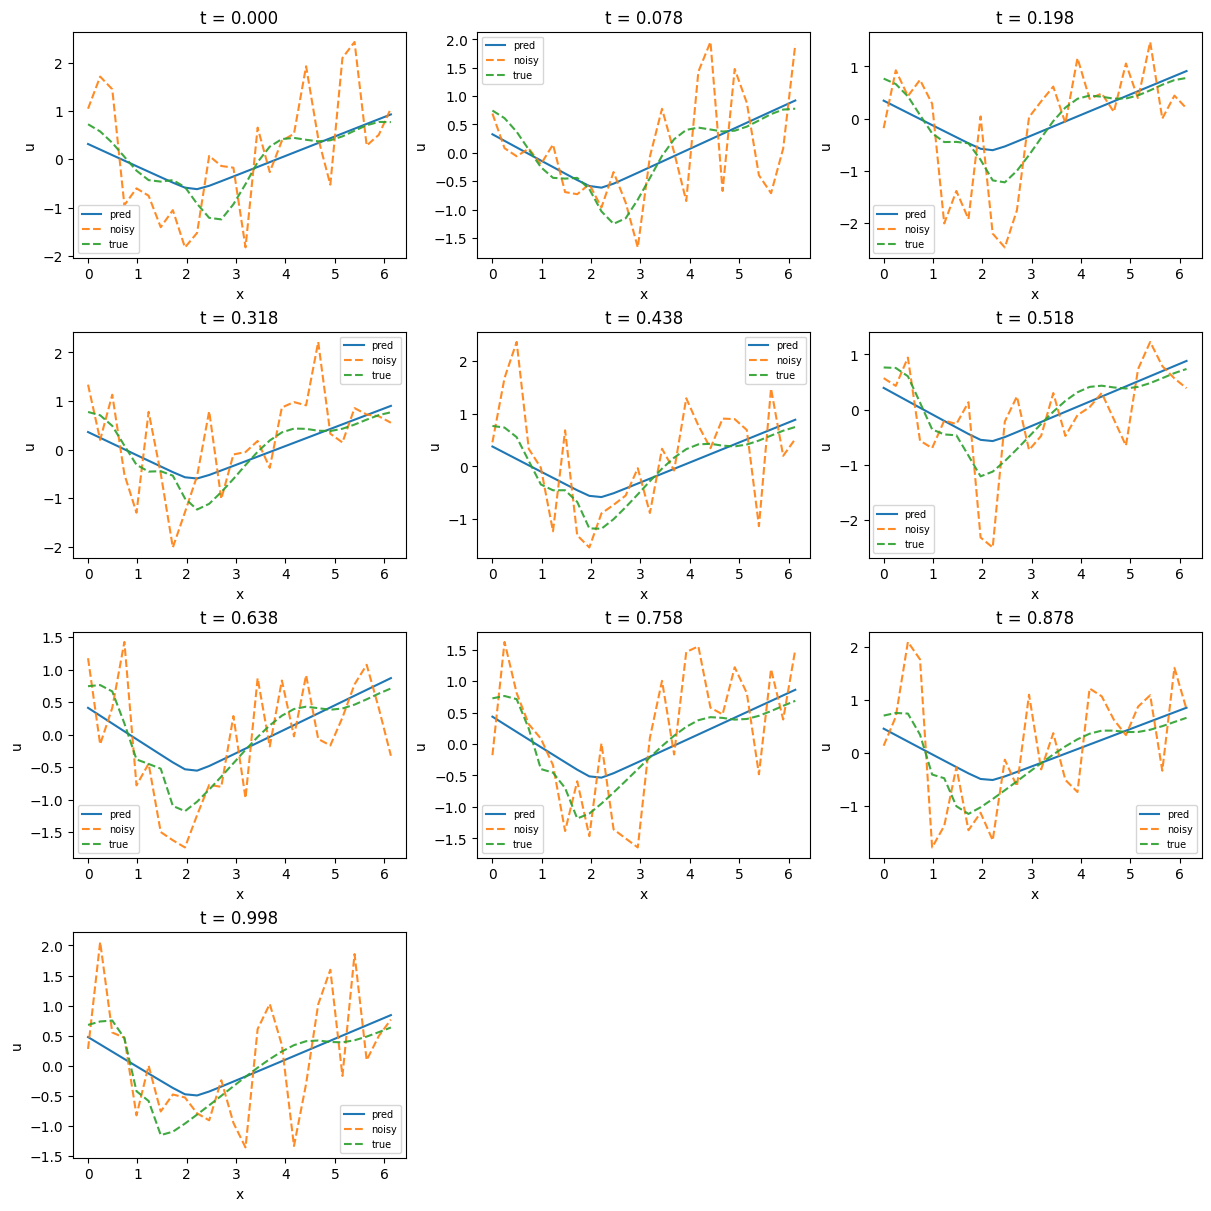

In [11]:
# Run sweep

results = []
for lam_tv in lam_tv_values:
    print('==============================')
    print('Running lam_tv =', lam_tv)
    print('==============================')
    results.append(run_once(lam_tv))


In [ ]:
# Sweep 1 [0, 1e-3, 1e-1, 1, 10]

try:
    import pandas as pd
except ImportError:
    pd = None

cols = [
    'lam_tv',
    'loss_data_final','loss_pde_final','loss_tv_final',
    'w_u','w_ux','w_uxx','w_prod',
    'M01','M10'
]

rows = [{k: r[k] for k in cols} for r in results]

if pd is not None:
    df = pd.DataFrame(rows).sort_values(['lam_tv']).reset_index(drop=True)
    display(df)
    print('Markdown table (paste into email):')
    print(df.to_markdown(index=False))
else:
    print(rows)


,lam_tv,loss_data_final,loss_pde_final,loss_tv_final,w_u,w_ux,w_uxx,w_prod,M01,M10
0,0.000,0.459680,0.187138,5.540967,0.058569,0.331093,-0.019775,-0.525547,-0.173080,-0.062836
1,0.001,0.462681,0.190713,4.951190,0.069124,0.323246,-0.019563,-0.537816,-0.205145,-0.075671
2,0.100,0.482073,0.099491,1.414729,0.048668,0.224753,-0.004277,-0.666938,-0.714972,0.001403
3,1.000,0.516128,0.024395,0.392883,-0.183360,0.158501,0.118165,-0.468080,-0.280671,-0.014723
4,10.000,0.619731,0.000654,0.112192,-0.224494,0.003689,0.039359,-0.521782,-0.234353,-0.000425


Markdown table (paste into email):
|   lam_tv |   loss_data_final |   loss_pde_final |   loss_tv_final |        w_u |       w_ux |       w_uxx |    w_prod |       M01 |          M10 |
|---------:|------------------:|-----------------:|----------------:|-----------:|-----------:|------------:|----------:|----------:|-------------:|
|    0     |          0.45968  |      0.187138    |        5.54097  |  0.0585693 | 0.331093   | -0.0197752  | -0.525547 | -0.17308  | -0.0628362   |
|    0.001 |          0.462681 |      0.190713    |        4.95119  |  0.0691242 | 0.323246   | -0.0195634  | -0.537816 | -0.205145 | -0.0756713   |
|    0.1   |          0.482073 |      0.0994915   |        1.41473  |  0.0486678 | 0.224753   | -0.00427734 | -0.666938 | -0.714972 |  0.00140279  |
|    1     |          0.516128 |      0.0243949   |        0.392883 | -0.18336   | 0.158501   |  0.118165   | -0.46808  | -0.280671 | -0.0147229   |
|   10     |          0.619731 |      0.000654469 |        0.112192 | -

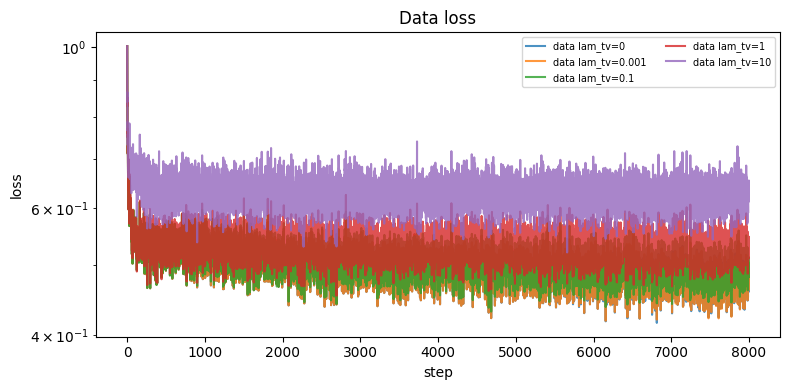

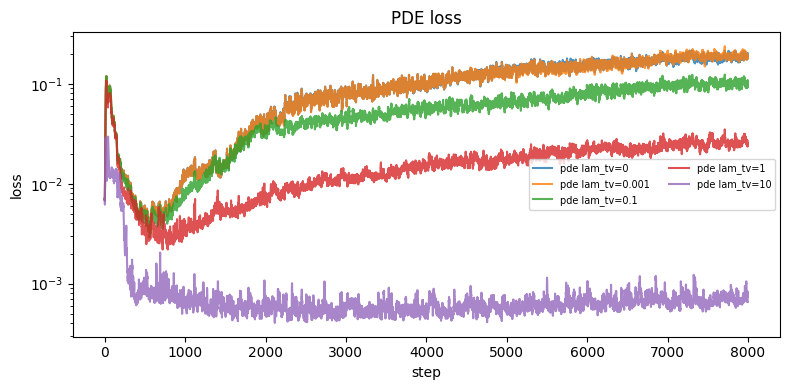

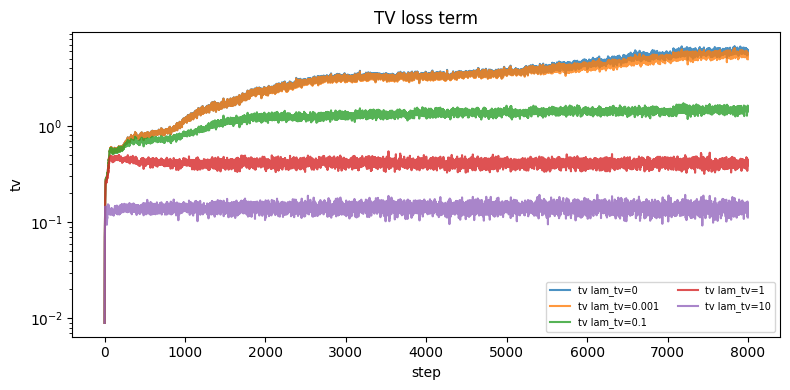

In [9]:
# Plot loss curves (data, pde, tv) per lam_tv

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_data_curve'], label=f"data lam_tv={r['lam_tv']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('Data loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_pde_curve'], label=f"pde lam_tv={r['lam_tv']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('PDE loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_tv_curve'], label=f"tv lam_tv={r['lam_tv']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('tv'); plt.title('TV loss term'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()


Sweep 2